# Top 10 Hottest Peppers in the World

How hot are the world's hottest peppers? How do they compare to those commonly used in cooking?

The Scoville Heat Unit (SHU) measures the spiciness of chili peppers. Originally, this involved diluting a pepper's alcohol-based extract in water until a panel of tasters could no longer detect the heat. The needed dilution determined the SHU. For example, if a pepper extract needed to be diluted 1,000 times before the heat was undetectable, it would be rated at 1,000 SHU.

Today, more accurate chemical methods determine SHU, but results are still expressed in Scoville Units.

The file `worlds-hottest-peppers.csv` lists the heat levels of the top 10 hottest peppers.

In [7]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'worlds-hottest-peppers.csv'.

# from google.colab import files
# uploaded = files.upload()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('worlds-hottest-peppers.csv')
df

,pepper,scoville_heat_unit
0,Pepper X,2693000
1,Carolina Reaper,2200000
2,Trinidad Moruga Scorpion,2009231
3,7 Pot Douglah,1853936
4,7 Pot Primo,1469000
5,Trinidad Scorpion,1463700
6,Naga Viper,1349000
7,Ghost Pepper,1041427
8,7 Pot Barrackpore,1000000
9,Red Savina Habanero,500000


### Project Ideas

- Create a horizontal bar plot displaying the Scoville units for each pepper.

- Follow the Pro Tips.

- Use color or a reference bar to help readers build intuition about the heat of these peppers.


#### Ideas for storytelling

- Compare the world's hottest peppers to common cooking varieties. For example, Jalapeños range from 2,500 to 8,000 Scoville units.

- Highlight the rapid development of hotter peppers; for instance, the Ghost Pepper held the record in 2007, but has since been surpassed.

In [9]:
# YOUR CODE HERE (add additional cells as needed)

In [10]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Dataset
# data = {
#     "pepper": [
#         "Bell Pepper",
#         "Jalapeño",
#         "Tabasco",
#         "Ghost Pepper",
#         "Carolina Reaper",
#         "Pepper X"
#     ],
    
#     "scoville_heat_unit": [
#         0,
#         5000,
#         40000,
#         1000000,
#         2200000,
#         2693000
#     ]
# }

# df = pd.DataFrame(data)

# # Sort values
# df = df.sort_values("scoville_heat_unit")

# # Plot
# plt.figure(figsize=(10,6))

# bars = plt.barh(
#     df["pepper"],
#     df["scoville_heat_unit"]
# )

# # Labels
# plt.xlabel("Scoville Heat Units (SHU)")
# plt.title("The World's Hottest Peppers")

# # Add values at end of bars
# for index, value in enumerate(df["scoville_heat_unit"]):
#     plt.text(value, index, f"{value:,}")

# plt.tight_layout()
# plt.show()

In [11]:
# ── Common cooking peppers for reference/comparison ───────────────────────────
reference_peppers = pd.DataFrame({
    'pepper': ['Bell Pepper', 'Jalapeño', 'Serrano', 'Cayenne', 'Tabasco', 'Habanero', 'Ghost Pepper'],
    'shu':    [0,             5000,       15000,     40000,     50000,     350000,      1000000],
    'type':   ['reference'] * 7
})

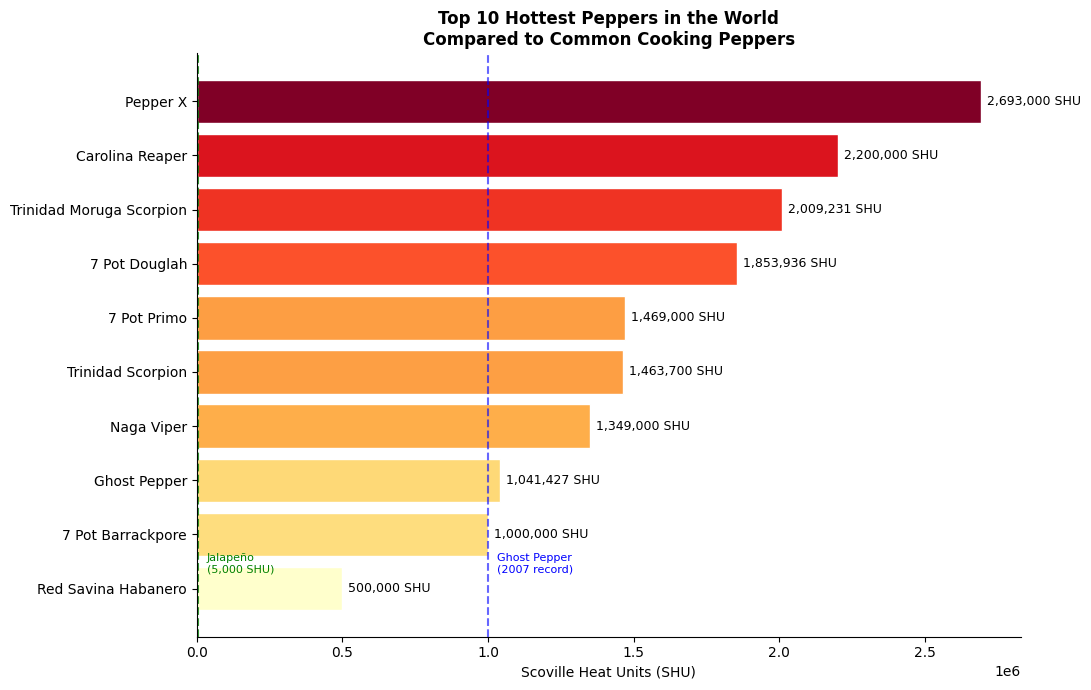

In [13]:
# ── 1. Main chart: Top 10 hottest peppers (from CSV) ──────────────────────────
df_sorted = df.sort_values('scoville_heat_unit', ascending=True)   # adjust col name if needed

# Color gradient: light yellow → deep red based on heat
import matplotlib.colors as mcolors
norm = plt.Normalize(df_sorted['scoville_heat_unit'].min(), df_sorted['scoville_heat_unit'].max())
cmap = plt.cm.YlOrRd
colors = [cmap(norm(v)) for v in df_sorted['scoville_heat_unit']]

plt.figure(figsize=(11, 7))
bars = plt.barh(df_sorted['pepper'], df_sorted['scoville_heat_unit'],
                color=colors, edgecolor='white')

# Value labels at end of each bar
for bar, val in zip(bars, df_sorted['scoville_heat_unit']):
    plt.text(bar.get_width() + 20000, bar.get_y() + bar.get_height() / 2,
             f'{val:,} SHU', va='center', fontsize=9)

# Reference line: Jalapeño (common cooking pepper)
jalapeno_shu = 5000
plt.axvline(x=jalapeno_shu, color='green', linestyle='--',
            linewidth=1.5, alpha=0.8)
plt.text(jalapeno_shu + 30000, 0.3, 'Jalapeño\n(5,000 SHU)',
         color='green', fontsize=8)

# Reference line: Ghost Pepper (former world record, 2007)
ghost_shu = 1000000
plt.axvline(x=ghost_shu, color='blue', linestyle='--',
            linewidth=1.5, alpha=0.6)
plt.text(ghost_shu + 30000, 0.3, 'Ghost Pepper\n(2007 record)',
         color='blue', fontsize=8)

plt.xlabel('Scoville Heat Units (SHU)')
plt.title("Top 10 Hottest Peppers in the World\nCompared to Common Cooking Peppers",
          fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

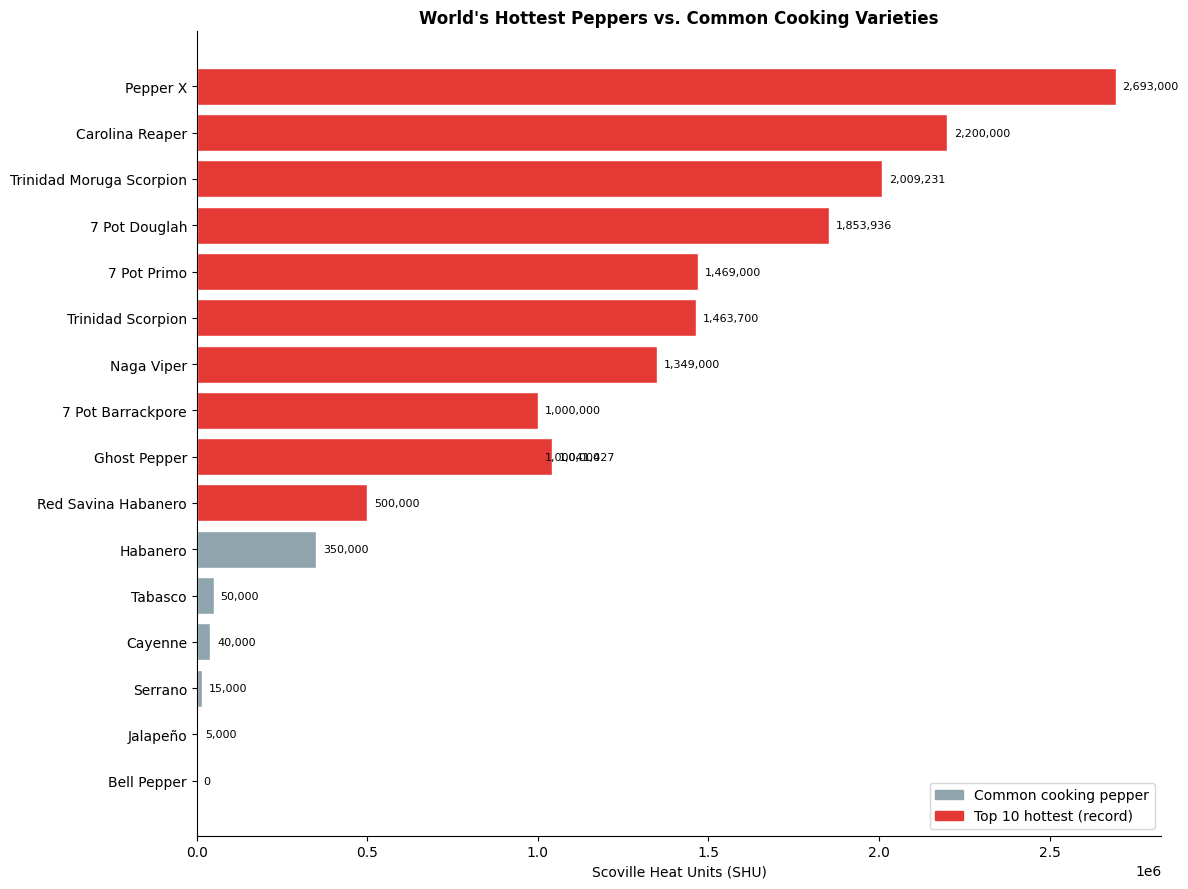

In [15]:
# ── 2. Comparison chart: Top 10 hottest vs common cooking peppers ─────────────
# Combine datasets
shu_col = 'scoville_heat_unit'   # adjust if your CSV column name differs
top10 = df[['pepper', shu_col]].copy()
top10['type'] = 'record pepper'
top10.rename(columns={shu_col: 'shu'}, inplace=True)

combined = pd.concat([reference_peppers[['pepper', 'shu', 'type']], top10], ignore_index=True)
combined = combined.sort_values('shu', ascending=True)

type_colors = {'reference': '#90A4AE', 'record pepper': '#E53935'}
bar_colors  = combined['type'].map(type_colors)

plt.figure(figsize=(12, 9))
bars = plt.barh(combined['pepper'], combined['shu'],
                color=bar_colors, edgecolor='white')

for bar, val in zip(bars, combined['shu']):
    plt.text(bar.get_width() + 20000, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#90A4AE', label='Common cooking pepper'),
    Patch(color='#E53935', label='Top 10 hottest (record)')
]
plt.legend(handles=legend_handles, loc='lower right')

plt.xlabel('Scoville Heat Units (SHU)')
plt.title("World's Hottest Peppers vs. Common Cooking Varieties", fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

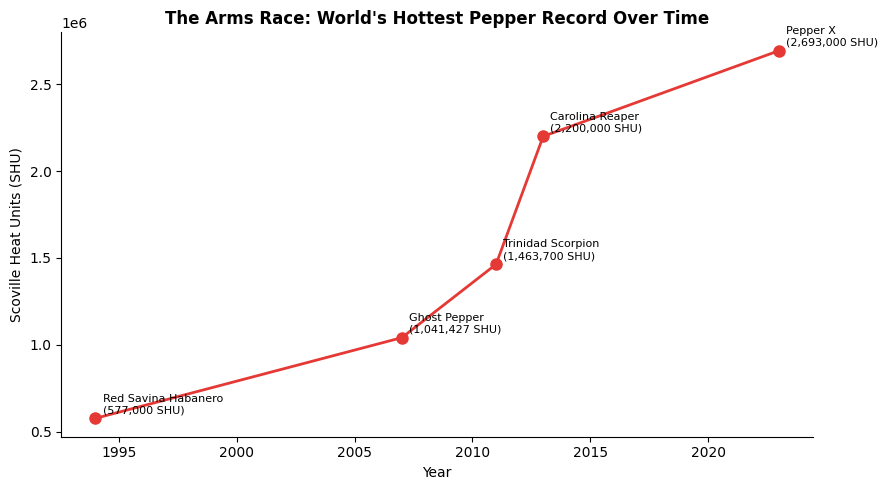

In [16]:
# ── 3. Storytelling: How fast did the record grow? ────────────────────────────
# Notable record holders with the year they took the title
record_history = pd.DataFrame({
    'pepper': ['Red Savina Habanero', 'Ghost Pepper', 'Trinidad Scorpion', 'Carolina Reaper', 'Pepper X'],
    'year':   [1994,                  2007,            2011,                2013,              2023],
    'shu':    [577000,                1041427,         1463700,             2200000,           2693000]
})

plt.figure(figsize=(9, 5))
plt.plot(record_history['year'], record_history['shu'],
         marker='o', color='#E53935', linewidth=2, markersize=8)

for _, row in record_history.iterrows():
    plt.text(row['year'] + 0.3, row['shu'] + 30000,
             f"{row['pepper']}\n({row['shu']:,} SHU)", fontsize=8)

plt.xlabel('Year')
plt.ylabel('Scoville Heat Units (SHU)')
plt.title("The Arms Race: World's Hottest Pepper Record Over Time", fontweight='bold')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()